In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import random

In [3]:
# Configurações do dispositivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Hiperparâmetros
BATCH_SIZE = 32
IMAGE_SIZE = 64  # Redimensionar imagens para 64x64
NC = 1  # Número de canais (1 para grayscale, 3 para RGB)
NZ = 100  # Tamanho do vetor de ruído
NGF = 64  # Número de features do gerador
NDF = 64  # Número de features do discriminador
NUM_EPOCHS = 200
LR = 0.0002
BETA1 = 0.5

Usando dispositivo: cuda:0


In [4]:
class MedicalImageDataset(Dataset):
    """Dataset customizado para imagens médicas"""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('L')  # Converter para grayscale
        
        if self.transform:
            image = self.transform(image)
        
        return image

def weights_init(m):
    """Inicialização de pesos para as redes"""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
class Generator(nn.Module):
    """Gerador DCGAN otimizado para imagens médicas"""
    def __init__(self, nz, ngf, nc):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Entrada: Z (nz x 1 x 1)
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            # Estado: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # Estado: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # Estado: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # Estado: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Saída: (nc) x 64 x 64
        )
    
    def forward(self, input):
        return self.main(input)

In [6]:
class Discriminator(nn.Module):
    """Discriminador DCGAN otimizado para imagens médicas"""
    def __init__(self, nc, ndf):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Entrada: (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Estado: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Estado: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Estado: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Estado: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # Saída: 1 x 1 x 1
        )
    
    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

In [7]:
class MedicalGAN:
    """Classe principal para treinar GANs para cada categoria médica"""
    
    def __init__(self, class_name, image_paths):
        self.class_name = class_name
        self.image_paths = image_paths
        
        # Transformações para as imagens
        self.transform = transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))  # Normalizar para [-1, 1]
        ])
        
        # Dataset e DataLoader
        self.dataset = MedicalImageDataset(image_paths, self.transform)
        self.dataloader = DataLoader(self.dataset, batch_size=BATCH_SIZE, 
                                   shuffle=True, num_workers=2)
        
        # Inicializar redes
        self.netG = Generator(NZ, NGF, NC).to(device)
        self.netD = Discriminator(NC, NDF).to(device)
        
        # Aplicar inicialização de pesos
        self.netG.apply(weights_init)
        self.netD.apply(weights_init)
        
        # Função de perda e otimizadores
        self.criterion = nn.BCELoss()
        self.optimizerD = optim.Adam(self.netD.parameters(), lr=LR, betas=(BETA1, 0.999))
        self.optimizerG = optim.Adam(self.netG.parameters(), lr=LR, betas=(BETA1, 0.999))
        
        # Labels reais e falsos
        self.real_label = 1.
        self.fake_label = 0.
        
        # Ruído fixo para visualização
        self.fixed_noise = torch.randn(64, NZ, 1, 1, device=device)
        
        # Listas para armazenar perdas
        self.G_losses = []
        self.D_losses = []
        
    def train(self):
        """Treinar a GAN"""
        print(f"Iniciando treinamento para classe: {self.class_name}")
        print(f"Número de imagens: {len(self.dataset)}")
        
        for epoch in range(NUM_EPOCHS):
            for i, data in enumerate(self.dataloader, 0):
                ############################
                # (1) Atualizar Discriminador: maximizar log(D(x)) + log(1 - D(G(z)))
                ###########################
                self.netD.zero_grad()
                
                # Treinar com lote real
                real_data = data.to(device)
                b_size = real_data.size(0)
                label = torch.full((b_size,), self.real_label, 
                                 dtype=torch.float, device=device)
                
                output = self.netD(real_data)
                errD_real = self.criterion(output, label)
                errD_real.backward()
                D_x = output.mean().item()
                
                # Treinar com lote falso
                noise = torch.randn(b_size, NZ, 1, 1, device=device)
                fake = self.netG(noise)
                label.fill_(self.fake_label)
                output = self.netD(fake.detach())
                errD_fake = self.criterion(output, label)
                errD_fake.backward()
                D_G_z1 = output.mean().item()
                errD = errD_real + errD_fake
                self.optimizerD.step()
                
                ############################
                # (2) Atualizar Gerador: maximizar log(D(G(z)))
                ###########################
                self.netG.zero_grad()
                label.fill_(self.real_label)
                output = self.netD(fake)
                errG = self.criterion(output, label)
                errG.backward()
                D_G_z2 = output.mean().item()
                self.optimizerG.step()
                
                # Estatísticas
                if i % 50 == 0:
                    print(f'[{epoch}/{NUM_EPOCHS}][{i}/{len(self.dataloader)}] '
                          f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                          f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')
                
                self.G_losses.append(errG.item())
                self.D_losses.append(errD.item())
            
            # Salvar imagens de exemplo a cada 25 épocas
            if epoch % 25 == 0:
                self.save_sample_images(epoch)
        
        # Salvar modelos treinados
        self.save_models()
        print(f"Treinamento concluído para classe: {self.class_name}")
    
    def save_sample_images(self, epoch):
        """Salvar imagens de exemplo durante o treinamento"""
        with torch.no_grad():
            fake = self.netG(self.fixed_noise).detach().cpu()
            
        # Criar diretório se não existir
        os.makedirs(f'samples_{self.class_name}', exist_ok=True)
        
        vutils.save_image(fake, f'samples_{self.class_name}/fake_samples_epoch_{epoch:03d}.png',
                         normalize=True, nrow=8)
    
    def save_models(self):
        """Salvar os modelos treinados"""
        os.makedirs('models', exist_ok=True)
        torch.save(self.netG.state_dict(), f'models/generator_{self.class_name}.pth')
        torch.save(self.netD.state_dict(), f'models/discriminator_{self.class_name}.pth')
    
    def generate_images(self, num_images):
        """Gerar novas imagens"""
        self.netG.eval()
        generated_images = []
        
        with torch.no_grad():
            for i in range(0, num_images, BATCH_SIZE):
                batch_size = min(BATCH_SIZE, num_images - i)
                noise = torch.randn(batch_size, NZ, 1, 1, device=device)
                fake_images = self.netG(noise)
                
                # Desnormalizar e converter para PIL
                fake_images = (fake_images + 1) / 2.0  # [-1, 1] -> [0, 1]
                for j in range(batch_size):
                    img_tensor = fake_images[j].cpu()
                    img_pil = transforms.ToPILImage()(img_tensor)
                    generated_images.append(img_pil)
        
        return generated_images
    
    def plot_losses(self):
        """Plotar as perdas durante o treinamento"""
        plt.figure(figsize=(10, 5))
        plt.title(f"Perdas do Gerador e Discriminador - {self.class_name}")
        plt.plot(self.G_losses, label="G")
        plt.plot(self.D_losses, label="D")
        plt.xlabel("Iterações")
        plt.ylabel("Perda")
        plt.legend()
        plt.savefig(f'losses_{self.class_name}.png')
        plt.show()

def prepare_dataset_paths(base_path):
    """
    Preparar caminhos das imagens por classe
    Estrutura esperada:
    base_path/
    ├── covid19/
    ├── normal/
    ├── pneumonia_bacterial/
    └── pneumonia_viral/
    """
    dataset_info = {
        'covid19': {'current': 10000, 'target': 15700},
        'normal': {'current': 15700, 'target': 15700},  # Já balanceado
        'pneumonia_bacterial': {'current': 5500, 'target': 15700},
        'pneumonia_viral': {'current': 3000, 'target': 15700}
    }
    
    paths = {}
    for class_name in dataset_info.keys():
        class_path = Path(base_path) / class_name
        if class_path.exists():
            paths[class_name] = list(class_path.glob('*.png')) + \
                               list(class_path.glob('*.jpg')) + \
                               list(class_path.glob('*.jpeg'))
        else:
            print(f"Aviso: Diretório {class_path} não encontrado")
            paths[class_name] = []
    
    return paths, dataset_info

In [8]:
def plot_losses(self):
        """Plotar as perdas durante o treinamento"""
        plt.figure(figsize=(10, 5))
        plt.title(f"Perdas do Gerador e Discriminador - {self.class_name}")
        plt.plot(self.G_losses, label="G")
        plt.plot(self.D_losses, label="D")
        plt.xlabel("Iterações")
        plt.ylabel("Perda")
        plt.legend()
        plt.savefig(f'losses_{self.class_name}.png')
        plt.show()

In [9]:
def prepare_dataset_paths(base_path):
    """
    Preparar caminhos das imagens por classe
    Estrutura esperada:
    base_path/
    ├── covid19/
    ├── normal/
    ├── pneumonia_bacterial/
    └── pneumonia_viral/
    """
    dataset_info = {
        'covid19': {'current': 10000, 'target': 15700},
        'normal': {'current': 15700, 'target': 15700},  # Já balanceado
        'pneumonia_bacterial': {'current': 5500, 'target': 15700},
        'pneumonia_viral': {'current': 3000, 'target': 15700}
    }
    
    paths = {}
    for class_name in dataset_info.keys():
        class_path = Path(base_path) / class_name
        if class_path.exists():
            paths[class_name] = list(class_path.glob('*.png')) + \
                               list(class_path.glob('*.jpg')) + \
                               list(class_path.glob('*.jpeg'))
        else:
            print(f"Aviso: Diretório {class_path} não encontrado")
            paths[class_name] = []
    
    return paths, dataset_info

In [10]:
def balance_dataset(base_path):
    """Função principal para balancear o dataset"""
    paths, dataset_info = prepare_dataset_paths(base_path)
    
    # Classes que precisam de mais imagens
    classes_to_augment = ['pneumonia_viral', 'pneumonia_bacterial', 'covid19']
    
    gans = {}
    
    for class_name in classes_to_augment:
        if class_name in paths and len(paths[class_name]) > 0:
            print(f"\n=== Treinando GAN para {class_name} ===")
            
            # Criar e treinar GAN
            gan = MedicalGAN(class_name, paths[class_name])
            gan.train()
            gan.plot_losses()
            
            # Calcular quantas imagens gerar
            current_count = dataset_info[class_name]['current']
            target_count = dataset_info[class_name]['target']
            images_to_generate = target_count - current_count
            
            if images_to_generate > 0:
                print(f"Gerando {images_to_generate} imagens para {class_name}")
                
                # Gerar e salvar novas imagens
                generated_images = gan.generate_images(images_to_generate)
                
                # Salvar imagens geradas
                output_dir = Path(f'generated_{class_name}')
                output_dir.mkdir(exist_ok=True)
                
                for i, img in enumerate(generated_images):
                    img.save(output_dir / f'generated_{class_name}_{i:04d}.png')
                
                print(f"Imagens salvas em: {output_dir}")
            
            gans[class_name] = gan
    
    return gans

Iniciando balanceamento do dataset médico...
Dataset atual:
- COVID-19: 10,000 imagens
- Normal: 15,700 imagens
- Pneumonia Bacteriana: 5,500 imagens
- Pneumonia Viral: 3,000 imagens

Objetivo: 15,700 imagens para cada classe

=== Treinando GAN para pneumonia_viral ===
Iniciando treinamento para classe: pneumonia_viral
Número de imagens: 2978
[0/200][0/94] Loss_D: 2.1774 Loss_G: 4.2632 D(x): 0.4511 D(G(z)): 0.6505 / 0.0177
[0/200][50/94] Loss_D: 0.0010 Loss_G: 37.5915 D(x): 0.9990 D(G(z)): 0.0000 / 0.0000
[1/200][0/94] Loss_D: 0.0003 Loss_G: 27.7800 D(x): 0.9997 D(G(z)): 0.0000 / 0.0000
[1/200][50/94] Loss_D: 1.2536 Loss_G: 11.8683 D(x): 0.9594 D(G(z)): 0.5645 / 0.0000
[2/200][0/94] Loss_D: 0.3803 Loss_G: 3.7441 D(x): 0.9700 D(G(z)): 0.2574 / 0.0440
[2/200][50/94] Loss_D: 0.3398 Loss_G: 3.3426 D(x): 0.8613 D(G(z)): 0.1230 / 0.0497
[3/200][0/94] Loss_D: 1.5651 Loss_G: 5.0901 D(x): 0.3801 D(G(z)): 0.0140 / 0.0418
[3/200][50/94] Loss_D: 0.4635 Loss_G: 4.5282 D(x): 0.7261 D(G(z)): 0.0632 /

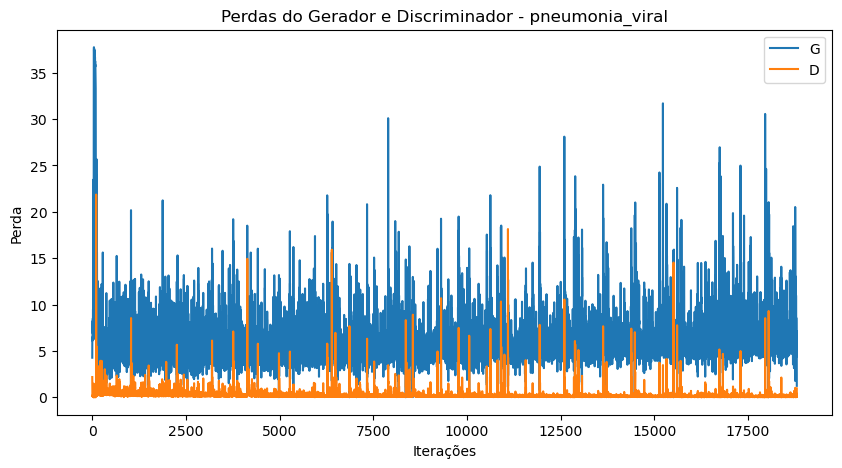

Gerando 12700 imagens para pneumonia_viral
Imagens salvas em: generated_pneumonia_viral

=== Treinando GAN para pneumonia_bacterial ===
Iniciando treinamento para classe: pneumonia_bacterial
Número de imagens: 5540
[0/200][0/174] Loss_D: 1.8542 Loss_G: 2.2861 D(x): 0.2919 D(G(z)): 0.2757 / 0.1179
[0/200][50/174] Loss_D: 0.1320 Loss_G: 8.3425 D(x): 0.9243 D(G(z)): 0.0275 / 0.0006
[0/200][100/174] Loss_D: 1.2980 Loss_G: 8.3981 D(x): 0.4602 D(G(z)): 0.0027 / 0.0004
[0/200][150/174] Loss_D: 0.9859 Loss_G: 9.5912 D(x): 0.9082 D(G(z)): 0.5207 / 0.0001
[1/200][0/174] Loss_D: 0.2164 Loss_G: 6.4884 D(x): 0.8438 D(G(z)): 0.0103 / 0.0020
[1/200][50/174] Loss_D: 0.6605 Loss_G: 5.7638 D(x): 0.9459 D(G(z)): 0.4066 / 0.0103
[1/200][100/174] Loss_D: 1.0494 Loss_G: 2.5475 D(x): 0.5036 D(G(z)): 0.0432 / 0.1746
[1/200][150/174] Loss_D: 0.4487 Loss_G: 3.3422 D(x): 0.8257 D(G(z)): 0.1675 / 0.0517
[2/200][0/174] Loss_D: 0.7484 Loss_G: 5.5076 D(x): 0.9534 D(G(z)): 0.4021 / 0.0141
[2/200][50/174] Loss_D: 1.29

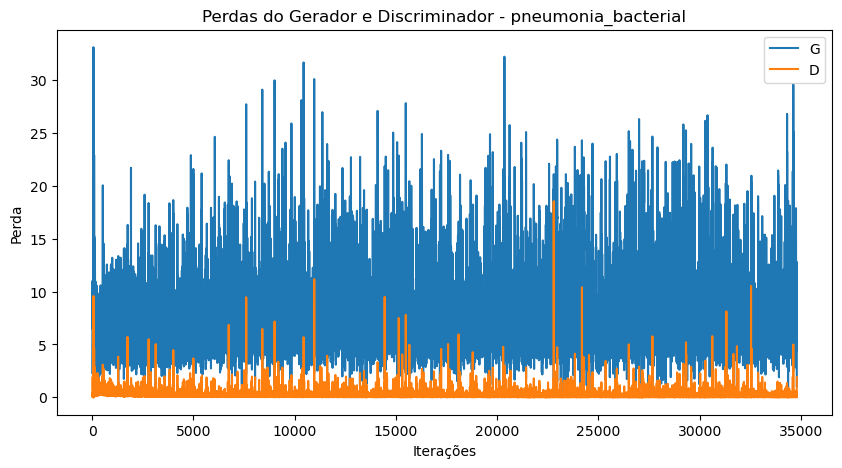

Gerando 10200 imagens para pneumonia_bacterial
Imagens salvas em: generated_pneumonia_bacterial

=== Treinando GAN para covid19 ===
Iniciando treinamento para classe: covid19
Número de imagens: 10010
[0/200][0/313] Loss_D: 1.0803 Loss_G: 4.5318 D(x): 0.5517 D(G(z)): 0.2916 / 0.0137
[0/200][50/313] Loss_D: 0.0001 Loss_G: 38.2982 D(x): 0.9999 D(G(z)): 0.0000 / 0.0000
[0/200][100/313] Loss_D: 0.0004 Loss_G: 37.9648 D(x): 0.9996 D(G(z)): 0.0000 / 0.0000
[0/200][150/313] Loss_D: 0.0000 Loss_G: 36.8938 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000
[0/200][200/313] Loss_D: 0.0003 Loss_G: 34.5876 D(x): 0.9997 D(G(z)): 0.0000 / 0.0000
[0/200][250/313] Loss_D: 0.0002 Loss_G: 39.5606 D(x): 0.9998 D(G(z)): 0.0000 / 0.0000
[0/200][300/313] Loss_D: 0.0000 Loss_G: 39.4787 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000
[1/200][0/313] Loss_D: 0.0000 Loss_G: 39.7853 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000
[1/200][50/313] Loss_D: 0.0000 Loss_G: 39.4061 D(x): 1.0000 D(G(z)): 0.0000 / 0.0000
[1/200][100/313] Loss_D: 0.0000 L

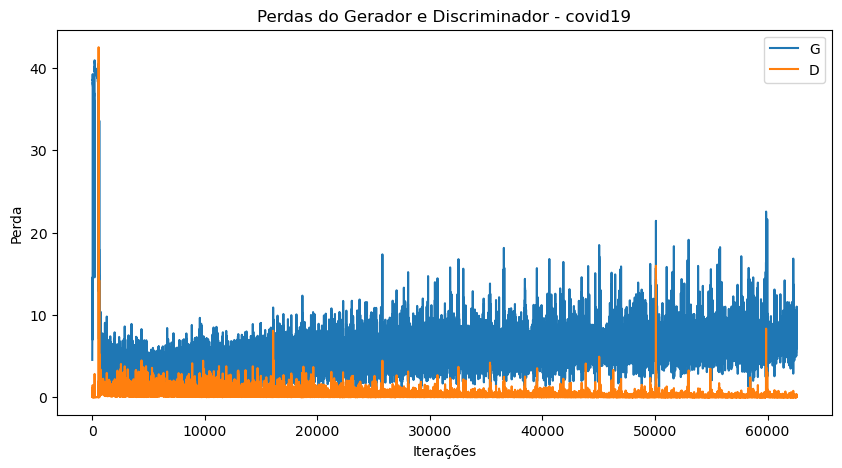

Gerando 5700 imagens para covid19
Imagens salvas em: generated_covid19

Para usar este código:
1. Organize suas imagens na estrutura de pastas especificada
2. Altere BASE_PATH para o caminho do seu dataset
3. Execute balance_dataset(BASE_PATH)
4. As imagens geradas serão salvas em pastas 'generated_[classe]'


In [12]:
# Exemplo de uso
if __name__ == "__main__":
    # Definir caminho base do dataset
    BASE_PATH = "./dataSetPibic/train"  # Altere para o caminho do seu dataset
    
    print("Iniciando balanceamento do dataset médico...")
    print("Dataset atual:")
    print("- COVID-19: 10,000 imagens")
    print("- Normal: 15,700 imagens")
    print("- Pneumonia Bacteriana: 5,500 imagens")
    print("- Pneumonia Viral: 3,000 imagens")
    print("\nObjetivo: 15,700 imagens para cada classe")
    
    # Balancear dataset
    trained_gans = balance_dataset(BASE_PATH)
    
    print("\nPara usar este código:")
    print("1. Organize suas imagens na estrutura de pastas especificada")
    print("2. Altere BASE_PATH para o caminho do seu dataset")
    print("3. Execute balance_dataset(BASE_PATH)")
    print("4. As imagens geradas serão salvas em pastas 'generated_[classe]'")